# AdroitHandDoor — SAC

Desarrollo incremental de los capítulos 1–5. El Capítulo 6 (informe técnico) queda fuera de este DWP y pendiente para la entrega académica. Las salidas locales no prueban ejecución en Colab.

## Capítulo 1 — Librerías, bootstrap y variables transversales

Se preserva el entorno `AdroitHandDoor-v1`, incluida la recompensa histórica. Las versiones siguientes son una combinación validada localmente; su validación definitiva en Colab está pendiente.

In [1]:
import os
import sys
import subprocess


IN_COLAB = "google.colab" in sys.modules


# Dependencias específicas y controladas del proyecto.
# No fijamos NumPy, PyTorch, SciPy, TensorFlow, Pandas ni Pillow:
# usamos las versiones nativas compatibles del runtime de Colab.
DEPENDENCIES = {
   "gymnasium-robotics": "1.4.2",
   "gymnasium": "1.3.0",
   "mujoco": "3.2.7",
   "stable-baselines3": "2.9.0",
}


if IN_COLAB:
   # Renderizado headless para MuJoCo en Colab.
   os.environ["MUJOCO_GL"] = "egl"


   packages = [
       *[f"{name}=={version}" for name, version in DEPENDENCIES.items()],
       "imageio",
       "imageio-ffmpeg",
   ]


   subprocess.run(
       [
           sys.executable,
           "-m",
           "pip",
           "install",
           "--disable-pip-version-check",
           *packages,
       ],
       check=True,
   )


print("Instalación de dependencias específicas completada.")


if IN_COLAB:
   print(
       "Se conservaron las versiones nativas de "
       "NumPy, PyTorch, SciPy, TensorFlow, Pandas y Pillow."
   )


Instalación de dependencias específicas completada.
Se conservaron las versiones nativas de NumPy, PyTorch, SciPy, TensorFlow, Pandas y Pillow.


In [2]:
import sys
import numpy as np
import pandas as pd
import scipy
import torch
import mujoco
import gymnasium as gym
import gymnasium_robotics
import stable_baselines3


gym.register_envs(gymnasium_robotics)


print("Python:", sys.version)
print("Gymnasium Robotics:", gymnasium_robotics.__version__)
print("Gymnasium:", gym.__version__)
print("MuJoCo:", mujoco.__version__)
print("Stable-Baselines3:", stable_baselines3.__version__)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)


print("\nEntorno científico: PASS")


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Gymnasium Robotics: 1.4.2
Gymnasium: 1.3.0
MuJoCo: 3.2.7
Stable-Baselines3: 2.9.0
PyTorch: 2.11.0+cpu
NumPy: 2.1.3
Pandas: 2.2.3
SciPy: 1.16.3

Entorno científico: PASS


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:


ENV_ID = "AdroitHandDoor-v1"
SEED = 42


env = gym.make(
   ENV_ID,
   render_mode="rgb_array",
)


obs, info = env.reset(seed=SEED)


print("Environment:", env.spec.id)
print("Observation shape:", obs.shape)
print("Action space:", env.action_space)
print("Max episode steps:", env.spec.max_episode_steps)


assert obs.shape == (39,)
assert env.action_space.shape == (28,)


action = env.action_space.sample()
next_obs, reward, terminated, truncated, info = env.step(action)


assert next_obs.shape == (39,)
assert np.isfinite(reward)


frame = env.render()
assert frame is not None
assert frame.ndim == 3


print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Render shape:", frame.shape)
print("Environment smoke test: PASS")


env.close()



Environment: AdroitHandDoor-v1
Observation shape: (39,)
Action space: Box(-1.0, 1.0, (28,), float32)
Max episode steps: 200
Reward: -0.23338023334319305
Terminated: False
Truncated: False
Render shape: (480, 480, 3)
Environment smoke test: PASS


In [4]:
import hashlib
import inspect
import json
import platform
import random
import time
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

import gymnasium as gym
import gymnasium_robotics
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import SAC
from IPython.display import display

CONFIG = {
    "env_id": "AdroitHandDoor-v1", "algorithm": "SAC", "policy": "MlpPolicy",
    "profile": "full", "timesteps": {"smoke": 5_000, "full": 500_000},
    "train_seed": 42, "baseline_seeds": list(range(101, 111)), "tuning_seeds": list(range(201, 206)),
    "final_seeds": list(range(1001, 1011)), "video_seed": 301,
    "eval_freq": 25_000, "checkpoint_freq": 50_000,
    "smoke_eval_freq": 2_500, "smoke_checkpoint_freq": 2_500,
    "moving_average_episodes": 25,
    "target_success_rate": 0.80,
    "sac": {"learning_rate": 3e-4, "gamma": 0.99, "tau": 0.005,
            "batch_size": 256, "buffer_size": 500_000, "train_freq": 1,
            "gradient_steps": 1, "ent_coef": "auto", "target_entropy": "auto",
            "policy_kwargs": {"net_arch": [256, 256]}},
    "learning_starts": {"smoke": 500, "full": 10_000},
    "video_fps": 30, "video_episodes": 1, "device": "cpu", "torch_threads": 1,
    "smoke_eval_seeds": [401, 402],
    "expected_horizon": 200, "expected_frame_skip": 5,
    "obs_dim": 39, "action_dim": 28, "success_threshold": 1.35,
    "render_train": None, "render_video": "rgb_array",
}
# Una raíz: abrir desde la raíz del repo o desde la carpeta del notebook.
MODEL_FOLDER = "1-AdroitHandDoor"
PROJECT_ROOT = (Path("/content") / MODEL_FOLDER if IN_COLAB else
                Path.cwd() if Path.cwd().name == MODEL_FOLDER else Path.cwd() / MODEL_FOLDER)
MODEL_DIR = PROJECT_ROOT / "models"
VIDEO_DIR = PROJECT_ROOT / "videos"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
RUNS_DIR = PROJECT_ROOT / "runs"
SMOKE_DIR = PROJECT_ROOT.parent / "tmp" / "adroit_smoke"
FINAL_MODEL_PATH = MODEL_DIR / "adroit_hand_door_sac.zip"
FINAL_METADATA_PATH = FINAL_MODEL_PATH.with_suffix(".metadata.json")
for folder in (MODEL_DIR, VIDEO_DIR, RESULTS_DIR, FIGURES_DIR, RUNS_DIR):
    folder.mkdir(parents=True, exist_ok=True)
random.seed(CONFIG["train_seed"])
np.random.seed(CONFIG["train_seed"])
torch.manual_seed(CONFIG["train_seed"])
torch.set_num_threads(CONFIG["torch_threads"])
gym.register_envs(gymnasium_robotics)
VERSIONS = {name: version(name) for name in DEPENDENCIES}
assert VERSIONS == DEPENDENCIES, (VERSIONS, DEPENDENCIES)
HARDWARE = {"platform": platform.platform(), "machine": platform.machine(),
            "python": platform.python_version(), "cuda_available": torch.cuda.is_available(),
            "mps_available": torch.backends.mps.is_available(), "device": CONFIG["device"]}
print(json.dumps({"versions": VERSIONS, "hardware": HARDWARE}, indent=2))


{
  "versions": {
    "gymnasium-robotics": "1.4.2",
    "gymnasium": "1.3.0",
    "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0"
  },
  "hardware": {
    "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
    "machine": "x86_64",
    "python": "3.13.15",
    "cuda_available": false,
    "mps_available": false,
    "device": "cpu"
  }
}


In [5]:
def make_env(render_mode=None, seed=None):
    """Create the unmodified task environment and seed its spaces.

    Args:
        render_mode: Gymnasium rendering mode, or None for training.
        seed: Optional seed for reset and action/observation spaces.

    Returns:
        A Gymnasium environment owned by the caller, which must close it.
    """
    env = gym.make(CONFIG["env_id"], render_mode=render_mode)
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
        env.observation_space.seed(seed)
    return env


def evaluate_policy(model, seeds):
    """Evaluate full episodes without learning, using any-step success.

    Args:
        model: SB3 model for deterministic inference, or None for random actions.
        seeds: Environment seeds, one per episode.

    Returns:
        DataFrame of returns, lengths, success and physical diagnostics.
    """
    records = []
    env = make_env()
    try:
        for seed in seeds:
            obs, info = env.reset(seed=int(seed))
            env.action_space.seed(int(seed))
            total, length, success = 0.0, 0, False
            max_angle, min_distance = -float("inf"), float("inf")
            terminated = truncated = False
            while not (terminated or truncated):
                action = env.action_space.sample() if model is None else model.predict(obs, deterministic=True)[0]
                obs, reward, terminated, truncated, info = env.step(action)
                assert np.isfinite(reward) and np.isfinite(obs).all()
                total += float(reward)
                length += 1
                success = success or bool(info["success"])
                base = env.unwrapped
                max_angle = max(max_angle, float(base.data.qpos[base.door_hinge_addrs]))
                min_distance = min(min_distance, float(np.linalg.norm(
                    base.data.site_xpos[base.grasp_site_id] - base.data.site_xpos[base.handle_site_id])))
            records.append({"seed": int(seed), "episode_return": total, "episode_length": length,
                            "success": success, "success_any": success,
                            "max_door_hinge": max_angle, "min_palm_handle_distance": min_distance})
    finally:
        env.close()
    return pd.DataFrame(records)


{
  "captured_at": "2026-09-23T23:57:04.744033+00:00",
  "execution_target": "colab",
  "environment_id": "AdroitHandDoor-v1",
  "env_spec": "EnvSpec(id='AdroitHandDoor-v1', entry_point='gymnasium_robotics.envs.adroit_hand.adroit_door:AdroitHandDoorEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={'reward_type': 'dense', 'render_mode': 'rgb_array'}, namespace=None, name='AdroitHandDoor', version=1, additional_wrappers=(), vector_entry_point=None)",
  "versions": {
    "gymnasium-robotics": "1.4.2",
    "gymnasium": "1.3.0",
    "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0"
  },
  "hardware": {
    "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
    "machine": "x86_64",
    "python": "3.13.15",
    "cuda_available": false,
    "mps_available": false,
    "device": "cpu"
  },
  "max_episode_steps": 200,
  "frame_skip": 5,
  "action_space": "Box(-1.0, 1.0, (28,), float32)",
  "observation_space": "B

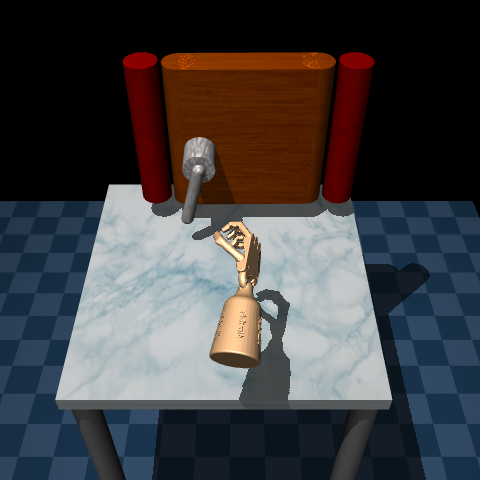

In [6]:
probe_env = make_env(render_mode=CONFIG["render_video"])
try:
    obs, info = probe_env.reset(seed=CONFIG["train_seed"])
    probe_env.action_space.seed(CONFIG["train_seed"])
    base = probe_env.unwrapped
    assert obs.shape == (CONFIG["obs_dim"],)
    assert probe_env.action_space.shape == (CONFIG["action_dim"],)
    assert np.all(probe_env.action_space.low == -1) and np.all(probe_env.action_space.high == 1)
    assert probe_env.spec.max_episode_steps == CONFIG["expected_horizon"]
    assert base.frame_skip == CONFIG["expected_frame_skip"]
    reward_samples = []
    for step in range(1, CONFIG["expected_horizon"] + 1):
        obs, reward, terminated, truncated, info = probe_env.step(probe_env.action_space.sample())
        assert np.isfinite(reward) and np.isfinite(obs).all()
        theta = float(base.data.qpos[base.door_hinge_addrs])
        distance = float(np.linalg.norm(base.data.site_xpos[base.grasp_site_id] -
                                        base.data.site_xpos[base.handle_site_id]))
        expected = 0.1 * distance - 0.1 * (theta - 1.57)**2 - 1e-5 * np.sum(base.data.qvel**2)
        expected += 2 * (theta > 0.2) + 8 * (theta > 1.0) + 10 * (theta > 1.35)
        assert np.isclose(reward, expected, rtol=1e-10, atol=1e-10)
        assert bool(info["success"]) == (theta >= CONFIG["success_threshold"])
        assert not terminated
        assert truncated == (step == CONFIG["expected_horizon"])
        if step <= 3:
            reward_samples.append({"step": step, "reward": float(reward),
                                   "reconstructed_reward": float(expected)})
    frame = probe_env.render()
    assert frame.ndim == 3 and frame.shape[-1] == 3
    actuators = []
    for i in range(base.model.nu):
        joint = int(base.model.actuator_trnid[i, 0])
        actuators.append({"name": base.model.actuator(i).name,
                          "ctrlrange": base.model.actuator_ctrlrange[i].tolist(),
                          "joint": base.model.joint(joint).name,
                          "joint_range": base.model.jnt_range[joint].tolist()})
    source = inspect.getsource(type(base).step)
    contract = {"captured_at": datetime.now(timezone.utc).isoformat(),
                "execution_target": "colab" if IN_COLAB else "local",
                "environment_id": probe_env.spec.id, "env_spec": str(probe_env.spec),
                "versions": VERSIONS, "hardware": HARDWARE,
                "max_episode_steps": probe_env.spec.max_episode_steps,
                "frame_skip": base.frame_skip, "action_space": str(probe_env.action_space),
                "observation_space": str(probe_env.observation_space), "actuators": actuators,
                "reward_distance_coefficient": 0.1, "reward_probe": reward_samples,
                "reward_source_sha256": hashlib.sha256(source.encode()).hexdigest(),
                "validated_steps": step, "truncated_at": step, "render_shape": list(frame.shape),
                "range_note": "Joint limits and actuator control ranges are distinct; no physics modifications."}
finally:
    probe_env.close()
contract["closed"] = True
(RESULTS_DIR / "runtime_contract.json").write_text(json.dumps(contract, indent=2) + "\n")
print(json.dumps(contract, indent=2))
from PIL import Image
display(Image.fromarray(frame))


## Capítulo 2 — Definición del agente

La mano controla 28 actuadores con acciones continuas normalizadas. La observación plana tiene 39 componentes. El objetivo físico es abrir la puerta: éxito si la bisagra alcanza 1.35 rad al menos una vez durante el episodio completo de 200 pasos. La recompensa conserva el término positivo de distancia de v1; mejorar retorno no garantiza abrir la puerta.

Primero medimos 10 episodios aleatorios con seeds 101–110. Las seeds de tuning (201–205), video (301) y evaluación final (1001–1010) quedan separadas. No se realiza aprendizaje en evaluación.

In [7]:
env = make_env(seed=CONFIG["train_seed"])
try:
    print("Observation:", env.observation_space)
    print("Action:", env.action_space)
finally:
    env.close()
random_df = evaluate_policy(None, CONFIG["baseline_seeds"])
random_df.to_csv(RESULTS_DIR / "random_baseline_initial.csv", index=False)
assert len(random_df) == 10
required = {"seed", "episode_return", "episode_length", "success", "max_door_hinge"}
assert required.issubset(random_df.columns)
assert random_df["episode_return"].notna().all()
assert random_df["success"].isin([True, False, 0, 1]).all()
assert (random_df["episode_length"] == CONFIG["expected_horizon"]).all()
assert set(CONFIG["baseline_seeds"]).isdisjoint(CONFIG["final_seeds"])
repeat_df = evaluate_policy(None, CONFIG["baseline_seeds"])
pd.testing.assert_frame_equal(random_df, repeat_df)
display(random_df)
print("Random return mean/std:", random_df.episode_return.mean(), random_df.episode_return.std(ddof=0))
print("Random success rate:", random_df.success.mean())


Observation: Box(-inf, inf, (39,), float64)
Action: Box(-1.0, 1.0, (28,), float32)


,seed,episode_return,episode_length,success,success_any,max_door_hinge,min_palm_handle_distance
0,101,-45.463074,200,False,False,0.011967,0.110129
1,102,-46.478753,200,False,False,0.011967,0.067836
2,103,-47.525282,200,False,False,0.017134,0.061592
3,104,-46.015255,200,False,False,0.011967,0.097042
4,105,-45.157018,200,False,False,0.011967,0.095949
5,106,-47.169673,200,False,False,0.019566,0.037850
6,107,-45.468734,200,False,False,0.011967,0.056714
7,108,-45.119038,200,False,False,0.011967,0.092612
8,109,-44.963236,200,False,False,0.011967,0.096736
9,110,-45.003949,200,False,False,0.011967,0.100599


Random return mean/std: -45.83640102538608 0.882080329538892
Random success rate: 0.0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Política y algoritmo

Usamos SAC de Stable-Baselines3: actor estocástico con entropía ajustada automáticamente y dos críticos para acciones continuas. Frente a TD3, su exploración por entropía es una hipótesis útil para coordinar 28 controles; frente a PPO, reutiliza transiciones mediante replay buffer. Estas ventajas conceptuales no garantizan resolver esta tarea con la recompensa de v1. La asignación mantiene la propuesta transversal SAC / TD3 / PPO para los tres modelos.

La `MlpPolicy` usa dos capas de 256 unidades con ReLU (default de SAC en SB3). Descuento 0.99, actualización suave 0.005, learning rate 0.0003 y batch 256. La tabla impresa es la configuración efectiva. El perfil smoke adelanta las actualizaciones a 500 pasos; full espera 10 000. No se normalizan observaciones/rewards ni se añade shaping. El criterio de selección será éxito, retorno, variabilidad y tiempo; 80% de éxito es un objetivo interno.

In [8]:
def build_model(train_env, profile="smoke"):
    """Construct SAC using the central configuration.

    Args:
        train_env: Environment used for training.
        profile: Either smoke or full.

    Returns:
        An untrained Stable-Baselines3 SAC model.
    """
    if profile not in CONFIG["timesteps"]:
        raise ValueError(f"Unknown profile: {profile}")
    return SAC(CONFIG["policy"], train_env, seed=CONFIG["train_seed"],
               device=CONFIG["device"], learning_starts=CONFIG["learning_starts"][profile],
               **CONFIG["sac"], verbose=0)

assert set(CONFIG["timesteps"]) == {"smoke", "full"}
assert set(CONFIG["tuning_seeds"]).isdisjoint(CONFIG["final_seeds"])
assert CONFIG["train_seed"] not in CONFIG["tuning_seeds"] + CONFIG["final_seeds"]
train_env = make_env(seed=CONFIG["train_seed"])
try:
    obs, _ = train_env.reset(seed=CONFIG["train_seed"])
    model = build_model(train_env, profile="smoke")
    action, _ = model.predict(obs, deterministic=False)
    assert action.shape == (28,)
    assert train_env.action_space.contains(action.astype(train_env.action_space.dtype))
    assert model.num_timesteps == 0
    try:
        build_model(train_env, profile="invalid")
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid profile accepted")
    print(model.policy)
    print(json.dumps(CONFIG, indent=2))
finally:
    train_env.close()


SACPolicy(
  (actor): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (latent_pi): Sequential(
      (0): Linear(in_features=39, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
    )
    (mu): Linear(in_features=256, out_features=28, bias=True)
    (log_std): Linear(in_features=256, out_features=28, bias=True)
  )
  (critic): ContinuousCritic(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (qf0): Sequential(
      (0): Linear(in_features=67, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=1, bias=True)
    )
    (qf1): Sequential(
      (0): Linear(in_features=67, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256,

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Capítulo 3 — Construcción y ejecución del entrenamiento

El smoke prueba actualizaciones reales, logs, guardado, recarga en un entorno nuevo y dos episodios de evaluación. Sus pesos son temporales y no constituyen el modelo final. Render desactivado durante aprendizaje.

In [9]:
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio


def file_sha256(path):
    """Return a file digest without loading the entire file in memory.

    Args:
        path: File to hash.

    Returns:
        Hexadecimal SHA-256 digest.
    """
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def record_video(model_path, output_path, title, seed, episodes=None, mode="smoke"):
    """Render a saved policy without learning and overlay cumulative reward.

    Args:
        model_path: Saved SAC model or checkpoint.
        output_path: Destination MP4.
        title: Visible evidence title.
        seed: First environment seed.
        episodes: Episode count, defaulting to central video configuration.
        mode: Smoke check, intermediate training checkpoint, or final inference.

    Returns:
        A provenance dictionary for the video.
    """
    if mode not in {"smoke", "intermediate", "final"}:
        raise ValueError(f"Unknown video mode: {mode}")
    loader = InferenceSAC if mode == "final" else SAC
    policy = loader.load(model_path, device=CONFIG["device"])
    env = make_env(render_mode=CONFIG["render_video"])
    episodes = CONFIG["video_episodes"] if episodes is None else episodes
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    font = ImageFont.load_default(size=19)
    count = 0
    try:
        with imageio.get_writer(output_path, fps=CONFIG["video_fps"], codec="libx264") as writer:
            for episode in range(episodes):
                obs, _ = env.reset(seed=seed + episode)
                total = 0.0
                terminated = truncated = False
                while not (terminated or truncated):
                    action, _ = policy.predict(obs, deterministic=True)
                    obs, reward, terminated, truncated, _ = env.step(action)
                    total += float(reward)
                    frame = Image.fromarray(env.render())
                    draw = ImageDraw.Draw(frame)
                    draw.rectangle((0, 0, frame.width, 64), fill="black")
                    draw.text((10, 6), title, fill="white", font=font)
                    draw.text((10, 34), f"Reward: {total:.2f} | Episode {episode + 1}", fill="white", font=font)
                    writer.append_data(np.asarray(frame))
                    count += 1
    finally:
        env.close()
    provenance = {"model": str(Path(model_path).relative_to(PROJECT_ROOT.parent)),
                  "model_sha256": file_sha256(model_path), "title": title,
                  "seed": seed, "episodes": episodes, "frames": count,
                  "fps": CONFIG["video_fps"], "model_timesteps": policy.num_timesteps,
                  "learning": False, "mode": mode}
    output_path.with_suffix(".json").write_text(json.dumps(provenance, indent=2) + "\n")
    return provenance


class TrainingEvidence(BaseCallback):
    """Persist monitoring episodes and identifiable intermediate checkpoints."""

    def __init__(self, run_dir, run_id, eval_freq, checkpoint_freq):
        """Initialize periodic evidence collection.

        Args:
            run_dir: Directory for the current run.
            run_id: Unique run identifier used in checkpoint names.
            eval_freq: Number of interaction steps between evaluations.
            checkpoint_freq: Number of interaction steps between saves.
        """
        super().__init__()
        self.run_dir, self.run_id = Path(run_dir), run_id
        self.eval_freq, self.checkpoint_freq = eval_freq, checkpoint_freq
        self.rows = []

    def _on_step(self):
        """Record deterministic tuning evaluation and save periodic checkpoints."""
        if self.num_timesteps % self.eval_freq == 0:
            assert all(torch.isfinite(v).all() for v in self.model.policy.state_dict().values())
            frame = evaluate_policy(self.model, CONFIG["tuning_seeds"])
            frame["timesteps"] = self.num_timesteps
            self.rows.extend(frame.to_dict("records"))
            pd.DataFrame(self.rows).to_csv(self.run_dir / "monitoring.csv", index=False)
            print(f"Step {self.num_timesteps}: return={frame.episode_return.mean():.2f}, "
                  f"success={frame.success.mean():.0%}, hinge={frame.max_door_hinge.mean():.3f}", flush=True)
        if self.num_timesteps % self.checkpoint_freq == 0:
            checkpoint = self.run_dir / "checkpoints" / f"{self.run_id}_{self.num_timesteps}_steps.zip"
            self.model.save(checkpoint)
            # One latest replay buffer enables recovery without ten large duplicates.
            self.model.save_replay_buffer(self.run_dir / "checkpoints" / "latest_replay_buffer.pkl")
        return True


def run_training(profile):
    """Train, checkpoint, save, reload and evaluate one SAC candidate.

    Args:
        profile: Smoke or full; all budgets come from CONFIG.

    Returns:
        Candidate path and its metadata dictionary.
    """
    if profile not in CONFIG["timesteps"]:
        raise ValueError(f"Unknown profile: {profile}")
    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ") + f"_{profile}"
    run_dir = (SMOKE_DIR if profile == "smoke" else RUNS_DIR) / run_id
    checkpoint_dir = run_dir / "checkpoints"
    checkpoint_dir.mkdir(parents=True, exist_ok=False)
    candidate_path = run_dir / f"{run_id}_candidate.zip"
    eval_freq = CONFIG["smoke_eval_freq"] if profile == "smoke" else CONFIG["eval_freq"]
    checkpoint_freq = CONFIG["smoke_checkpoint_freq"] if profile == "smoke" else CONFIG["checkpoint_freq"]
    callback = TrainingEvidence(run_dir, run_id, eval_freq, checkpoint_freq)
    train_env = Monitor(make_env(render_mode=CONFIG["render_train"], seed=CONFIG["train_seed"]), str(run_dir / "training.monitor.csv"))
    started_at = datetime.now(timezone.utc).isoformat()
    started = time.perf_counter()
    try:
        model = build_model(train_env, profile)
        initial = {k: v.detach().clone() for k, v in model.policy.state_dict().items()}
        model.learn(total_timesteps=CONFIG["timesteps"][profile], callback=callback)
        training_time_seconds = time.perf_counter() - started
        assert model.num_timesteps == CONFIG["timesteps"][profile]
        assert model._n_updates > 0
        assert all(torch.isfinite(v).all() for v in model.policy.state_dict().values())
        assert any(not torch.equal(v, initial[k]) for k, v in model.policy.state_dict().items())
        model.save(candidate_path)
        updates = model._n_updates
    finally:
        train_env.close()
    eval_env = make_env(seed=CONFIG["smoke_eval_seeds"][0])
    try:
        reloaded = SAC.load(candidate_path, env=eval_env, device=CONFIG["device"])
        obs, _ = eval_env.reset(seed=CONFIG["smoke_eval_seeds"][0])
        action, _ = reloaded.predict(obs, deterministic=True)
        assert action.shape == (CONFIG["action_dim"],)
        assert eval_env.action_space.contains(action.astype(eval_env.action_space.dtype))
        before = {k: v.detach().clone() for k, v in reloaded.policy.state_dict().items()}
        eval_df = evaluate_policy(reloaded, CONFIG["smoke_eval_seeds"])
        assert all(torch.equal(v, before[k]) for k, v in reloaded.policy.state_dict().items())
    finally:
        eval_env.close()
    eval_df.to_csv(run_dir / "reload_evaluation.csv", index=False)
    metadata = {"run_id": run_id, "profile": profile, "environment_id": CONFIG["env_id"],
                "algorithm": CONFIG["algorithm"], "seed": CONFIG["train_seed"],
                "total_timesteps": reloaded.num_timesteps, "gradient_updates": updates,
                "configuration": json.loads(json.dumps(CONFIG)), "versions": VERSIONS,
                "hardware": HARDWARE, "training_started_at": started_at,
                "training_finished_at": datetime.now(timezone.utc).isoformat(),
                "training_time_seconds": training_time_seconds,
                "candidate_path": str(candidate_path.relative_to(PROJECT_ROOT.parent)),
                "sha256": file_sha256(candidate_path),
                "evaluation_type": "reload smoke, not final evaluation",
                "evaluation_mean": eval_df.episode_return.mean(),
                "evaluation_std": eval_df.episode_return.std(ddof=0),
                "success_rate": eval_df.success.mean()}
    (run_dir / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
    assert checkpoint_dir.exists() and training_time_seconds > 0
    print(json.dumps(metadata, indent=2), flush=True)
    return candidate_path, metadata


In [10]:
candidate_path, run_metadata = run_training(CONFIG["profile"])
if CONFIG["profile"] == "smoke":
    smoke_video = candidate_path.parent / "smoke_video.mp4"
    record_video(candidate_path, smoke_video, "Training Process | Smoke check", CONFIG["video_seed"])
    reader = imageio.get_reader(smoke_video)
    try:
        assert reader.count_frames() == CONFIG["expected_horizon"] * CONFIG["video_episodes"]
        display(Image.fromarray(reader.get_data(0)))
    finally:
        reader.close()
    print("Smoke gates passed: training, checkpoint, reload, evaluation, MP4.")


Step 25000: return=-30.72, success=0%, hinge=0.012


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Step 50000: return=-39.96, success=0%, hinge=0.012


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Step 75000: return=-32.94, success=0%, hinge=0.012


...

Step 250000: return=-28.58, success=0%, hinge=0.012


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Step 275000: return=-27.96, success=0%, hinge=0.012


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


KeyboardInterrupt: 

### Selección y exportación del modelo

Se compara el candidato final con los checkpoints guardados de la misma corrida, usando exclusivamente las cinco seeds de tuning. Se ordena por éxito, retorno medio y menor desviación estándar. El checkpoint elegido puede ser anterior al final: la corrida no fue temporalmente estable y terminar más tarde no garantizó una política mejor. El registro conserva tanto los pasos del artefacto seleccionado como el presupuesto y tiempo de la corrida completa.

Si el mejor checkpoint alcanza el objetivo interno, se omiten nuevas corridas. De lo contrario se detiene aquí para ajustar la configuración conforme al máximo de dos corridas adicionales del DWP. Las seeds finales permanecen sin consultar.

La clase `InferenceSAC` solo adapta la serialización de SB3: guarda los pesos de la política sin estados de optimizer ni replay buffer. Se carga con `InferenceSAC.load`, no con `SAC.load`; las acciones deben ser idénticas a las del checkpoint original. El archivo canónico sirve para inferencia, y los checkpoints estándar permiten recuperar entrenamiento.

In [ ]:
class InferenceSAC(SAC):
    """SAC archive containing policy weights without training optimizer state."""

    def _get_torch_save_params(self):
        """Return only the policy state dictionary for serialization."""
        return ["policy"], []

    def _excluded_save_params(self):
        """Exclude training-only entropy tensors and optimizer objects."""
        return super()._excluded_save_params() + ["ent_coef_optimizer", "log_ent_coef", "ent_coef_tensor"]

    def learn(self, *args, **kwargs):
        """Reject training because this artifact is for inference only."""
        raise RuntimeError("Use a standard SAC checkpoint to resume training.")


In [ ]:
import zipfile
import shutil

if CONFIG["profile"] == "full":
    run_dir = candidate_path.parent
    paths = [candidate_path, *sorted((run_dir / "checkpoints").glob("*.zip"))]
    selection_rows = []
    for path in paths:
        candidate = SAC.load(path, device=CONFIG["device"])
        tuning_df = evaluate_policy(candidate, CONFIG["tuning_seeds"])
        selection_rows.append({"path": str(path.relative_to(PROJECT_ROOT.parent)),
                               "timesteps": candidate.num_timesteps,
                               "return_mean": tuning_df.episode_return.mean(),
                               "return_std": tuning_df.episode_return.std(ddof=0),
                               "success_rate": tuning_df.success.mean()})
    selection_df = pd.DataFrame(selection_rows).sort_values(
        ["success_rate", "return_mean", "return_std"], ascending=[False, False, True]).reset_index(drop=True)
    selection_df.to_csv(RESULTS_DIR / "checkpoint_selection.csv", index=False)
    selected = selection_df.iloc[0]
    display(selection_df)
    if selected.success_rate < CONFIG["target_success_rate"]:
        raise RuntimeError("Baseline below target: controlled tuning required before promotion; maximum two additional runs.")
    selected_path = PROJECT_ROOT.parent / selected.path
    selected_model = SAC.load(selected_path, device=CONFIG["device"])
    selected_tuning_df = evaluate_policy(selected_model, CONFIG["tuning_seeds"])
    assert np.isclose(selected_tuning_df.episode_return.mean(), selected.return_mean)
    assert selected_tuning_df.success.mean() == selected.success_rate
    export_env = make_env()
    try:
        inference = InferenceSAC(CONFIG["policy"], export_env, device=CONFIG["device"],
                                 **CONFIG["sac"])
        inference.set_parameters({"policy": selected_model.policy.state_dict()}, exact_match=True)
        inference.num_timesteps = selected_model.num_timesteps
        inference._n_updates = selected_model._n_updates
        inference.save(FINAL_MODEL_PATH)
        reloaded = InferenceSAC.load(FINAL_MODEL_PATH, env=export_env, device=CONFIG["device"])
        obs, _ = export_env.reset(seed=CONFIG["tuning_seeds"][0])
        for _ in range(CONFIG["expected_horizon"]):
            a, _ = selected_model.predict(obs, deterministic=True)
            b, _ = reloaded.predict(obs, deterministic=True)
            np.testing.assert_array_equal(a, b)
            obs, reward, terminated, truncated, info = export_env.step(b)
        assert truncated
        reloaded_df = evaluate_policy(reloaded, CONFIG["tuning_seeds"])
        pd.testing.assert_frame_equal(selected_tuning_df, reloaded_df)
    finally:
        export_env.close()
    with zipfile.ZipFile(FINAL_MODEL_PATH) as archive:
        assert "policy.pth" in archive.namelist()
        assert not any("optimizer" in name or "replay_buffer" in name for name in archive.namelist())
        assert "ent_coef_optimizer" not in json.loads(archive.read("data"))
    final_metadata = dict(run_metadata)
    final_metadata.update({"total_timesteps": int(selected.timesteps),
                           "run_total_timesteps": run_metadata["total_timesteps"],
                           "run_gradient_updates": run_metadata["gradient_updates"],
                           "gradient_updates": selected_model._n_updates,
                           "selected_checkpoint": selected.path,
                           "selected_checkpoint_sha256": file_sha256(selected_path),
                           "artifact": str(FINAL_MODEL_PATH.relative_to(PROJECT_ROOT.parent)),
                           "archive_kind": "InferenceSAC policy-only; load with InferenceSAC.load",
                           "sha256": file_sha256(FINAL_MODEL_PATH),
                           "evaluation_type": "tuning only; final evaluation pending",
                           "evaluation_mean": float(selected.return_mean),
                           "evaluation_std": float(selected.return_std),
                           "success_rate": float(selected.success_rate),
                           "tuning_omitted": True,
                           "limitation": "Temporal instability; selected checkpoint precedes end of run."})
    FINAL_METADATA_PATH.write_text(json.dumps(final_metadata, indent=2) + "\n")
    experiments_df = pd.DataFrame([{
        "run_id": run_metadata["run_id"], "change": "baseline; selected saved checkpoint; no hyperparameter tuning",
        "seed": CONFIG["train_seed"], "timesteps": run_metadata["total_timesteps"],
        "artifact_timesteps": int(selected.timesteps),
        "training_time_seconds": run_metadata["training_time_seconds"],
        "return_mean": float(selected.return_mean), "return_std": float(selected.return_std),
        "success_rate": float(selected.success_rate), "selected_checkpoint": selected.path}])
    experiments_df.to_csv(RESULTS_DIR / "experiments.csv", index=False)
    assert len(experiments_df) <= 3
    assert FINAL_MODEL_PATH.name == "adroit_hand_door_sac.zip"
    assert FINAL_METADATA_PATH.exists()
    assert file_sha256(FINAL_MODEL_PATH) == json.loads(FINAL_METADATA_PATH.read_text())["sha256"]
    for source, target in [("training.monitor.csv", "baseline_training.monitor.csv"),
                           ("monitoring.csv", "baseline_monitoring.csv"), ("metadata.json", "baseline_run.json")]:
        shutil.copyfile(run_dir / source, RESULTS_DIR / target)
    print("Selected checkpoint:", selected.path)
    print("Canonical model SHA-256:", final_metadata["sha256"])
else:
    print("Smoke profile: canonical delivery is not overwritten; no final evaluation or selection.")


,path,timesteps,return_mean,return_std,success_rate
0,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,450000,-27.547025,0.339815,0.0
1,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,400000,-27.567968,0.321112,0.0
2,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,300000,-27.663116,0.355262,0.0
3,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,250000,-27.845066,0.409078,0.0
4,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,500000,-27.861388,0.937365,0.0
5,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,500000,-27.873482,0.954759,0.0
6,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,200000,-28.034174,0.336181,0.0
7,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,150000,-28.894482,0.560000,0.0
8,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,100000,-28.923514,0.328761,0.0
9,1-AdroitHandDoor/runs/20260923T221043078684Z_f...,350000,-32.367091,0.351309,0.0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


RuntimeError: Baseline below target: controlled tuning required before promotion; maximum two additional runs.

/usr/local/lib/python3.13/dist-packages/IPython/core/history.py:576: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  self.db.execute("""UPDATE sessions SET end=?, num_cmds=? WHERE


## Capítulo 4 — Métricas y gráficas

La evaluación final carga explícitamente el artefacto canónico y utiliza 10 seeds reservadas (1001–1010), distintas de entrenamiento y tuning. Se mide el retorno completo de 200 pasos y éxito alcanzado al menos una vez, sin actualizar pesos. El baseline aleatorio usa las mismas seeds y horizonte.

Las tres métricas principales son el tiempo total de la corrida de entrenamiento, el retorno medio de evaluación ± desviación estándar poblacional y la tasa de éxito. La dispersión entre episodios no es un intervalo de confianza. Las figuras conservan todos los episodios y muestran la posición del checkpoint seleccionado dentro de la corrida completa.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

if CONFIG["profile"] == "full":
    final_metadata = json.loads(FINAL_METADATA_PATH.read_text())
    assert file_sha256(FINAL_MODEL_PATH) == final_metadata["sha256"]
    final_model = InferenceSAC.load(FINAL_MODEL_PATH, device=CONFIG["device"])
    before = {k: v.detach().clone() for k, v in final_model.policy.state_dict().items()}
    eval_df = evaluate_policy(final_model, CONFIG["final_seeds"])
    assert all(torch.equal(v, before[k]) for k, v in final_model.policy.state_dict().items())
    random_final_df = evaluate_policy(None, CONFIG["final_seeds"])
    eval_df.to_csv(RESULTS_DIR / "evaluation.csv", index=False)
    random_final_df.to_csv(RESULTS_DIR / "random_baseline_final.csv", index=False)
    assert len(eval_df) >= 10 and eval_df.seed.nunique() >= 10
    assert {"episode_return", "success_any", "max_door_hinge"}.issubset(eval_df.columns)
    assert len(random_final_df) == len(eval_df)
    assert set(random_final_df.seed) == set(eval_df.seed)
    assert (eval_df.episode_length == CONFIG["expected_horizon"]).all()
    assert (random_final_df.episode_length == CONFIG["expected_horizon"]).all()
    assert set(eval_df.seed).isdisjoint(CONFIG["tuning_seeds"])
    assert np.array_equal(eval_df.success_any, eval_df.max_door_hinge >= CONFIG["success_threshold"])
    metrics = {"training_time_seconds": final_metadata["training_time_seconds"],
               "evaluation_return_mean": eval_df.episode_return.mean(),
               "evaluation_return_std": eval_df.episode_return.std(ddof=0),
               "success_rate": eval_df.success_any.mean(), "evaluation_episodes": len(eval_df),
               "random_return_mean": random_final_df.episode_return.mean(),
               "random_return_std": random_final_df.episode_return.std(ddof=0),
               "random_success_rate": random_final_df.success_any.mean(),
               "model_sha256": final_metadata["sha256"], "run_id": final_metadata["run_id"],
               "artifact_timesteps": final_metadata["total_timesteps"],
               "run_total_timesteps": final_metadata["run_total_timesteps"]}
    (RESULTS_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2) + "\n")
    final_metadata.update({"evaluation_type": "final held-out deterministic evaluation",
                           "evaluation_seeds": CONFIG["final_seeds"],
                           "evaluation_mean": metrics["evaluation_return_mean"],
                           "evaluation_std": metrics["evaluation_return_std"],
                           "success_rate": metrics["success_rate"]})
    FINAL_METADATA_PATH.write_text(json.dumps(final_metadata, indent=2) + "\n")
    display(pd.DataFrame({"Métrica principal": ["Tiempo de entrenamiento (corrida completa)",
                                                  "Retorno de evaluación: media ± DE", "Tasa de éxito"],
                          "Valor": [f"{metrics['training_time_seconds'] / 60:.2f} min",
                                    f"{metrics['evaluation_return_mean']:.2f} ± {metrics['evaluation_return_std']:.2f}",
                                    f"{metrics['success_rate']:.0%} ({int(eval_df.success_any.sum())}/{len(eval_df)})"]}))
    display(eval_df)
    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                         "axes.spines.top": False, "axes.spines.right": False,
                         "axes.labelcolor": "#252525", "text.color": "#252525",
                         "figure.facecolor": "white", "axes.facecolor": "white"})
    blue, grey = "#245A91", "#929AA4"
    training_df = pd.read_csv(RESULTS_DIR / "baseline_training.monitor.csv", comment="#")
    steps = training_df.l.cumsum()
    fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
    ax.plot(steps, training_df.r, color=grey, alpha=.35, linewidth=.6, label="Retorno por episodio")
    ax.plot(steps, training_df.r.rolling(CONFIG["moving_average_episodes"], min_periods=1).mean(),
            color=blue, linewidth=1.8, label=f"Media móvil ({CONFIG['moving_average_episodes']} episodios)")
    ax.axvline(final_metadata["total_timesteps"], color="#333333", linestyle="--", linewidth=1.2,
               label=f"Modelo seleccionado ({final_metadata['total_timesteps']:,} pasos)")
    ax.set(title="1. Recompensa durante el entrenamiento", xlabel="Pasos de interacción", ylabel="Retorno por episodio")
    ax.set_xlim(0, final_metadata["run_total_timesteps"])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 1000:.0f}k"))
    ax.grid(axis="y", color="#E5E7EB"); ax.legend(loc="upper left", frameon=False)
    fig.savefig(FIGURES_DIR / "01_training_return.png", dpi=160); plt.show(); plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
    x = np.arange(1, len(eval_df) + 1)
    ax.bar(x, eval_df.episode_return, color=blue, width=.65)
    ax.axhline(metrics["evaluation_return_mean"], color="#333333", linestyle="--", linewidth=1.2, label="Media")
    for i, value, success in zip(x, eval_df.episode_return, eval_df.success_any):
        ax.annotate(f"{value:.0f}\n{'Éxito' if success else 'Sin éxito'}", (i, value),
                    xytext=(0, 5 if value >= 0 else -28), textcoords="offset points", ha="center", fontsize=9)
    ax.set(title="2. Evaluación final — 10 episodios reservados", xlabel="Episodio (seeds 1001–1010)", ylabel="Retorno acumulado")
    ax.set_xticks(x); ax.margins(y=.18); ax.axhline(0, color="#333333", linewidth=.8)
    ax.grid(axis="y", color="#E5E7EB"); ax.set_axisbelow(True); ax.legend(frameon=False)
    fig.savefig(FIGURES_DIR / "02_final_evaluation.png", dpi=160); plt.show(); plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
    groups = [random_final_df, eval_df]
    means = [frame.episode_return.mean() for frame in groups]
    stds = [frame.episode_return.std(ddof=0) for frame in groups]
    ax.bar([0, 1], means, color=[grey, blue], yerr=stds, capsize=7, width=.55,
           error_kw={"ecolor": "#333333", "elinewidth": 1.2})
    offsets = np.linspace(-.15, .15, len(eval_df))
    for i, frame in enumerate(groups):
        ax.scatter(i + offsets, frame.episode_return, color="#252525", s=18, zorder=3)
    ax.set_xticks([0, 1], [f"Random\nÉxito {random_final_df.success_any.mean():.0%}",
                            f"Trained\nÉxito {eval_df.success_any.mean():.0%}"])
    ax.set(title="3. Random vs Trained — mismas seeds y horizonte", ylabel="Retorno acumulado")
    ax.axhline(0, color="#333333", linewidth=.8); ax.grid(axis="y", color="#E5E7EB"); ax.set_axisbelow(True)
    ax.text(.02, .98, "Barras: media ± DE poblacional\nPuntos: 10 episodios por política", transform=ax.transAxes,
            va="top", fontsize=10)
    ax.margins(y=.17)
    fig.savefig(FIGURES_DIR / "03_random_vs_trained.png", dpi=160); plt.show(); plt.close(fig)
    figures_dir = FIGURES_DIR
    assert len(list(figures_dir.glob("*.png"))) == 3
    print(json.dumps(metrics, indent=2))
else:
    print("Smoke profile: final held-out evaluation and delivery figures are not generated.")


## Capítulo 5 — Videos

`training_process.mp4` usa el checkpoint real de mitad de la corrida (250000 pasos). `trained.mp4` carga el artefacto canónico seleccionado (450000 pasos). Ambos usan la seed de video 301, separada de las seeds de evaluación, y muestran recompensa acumulada en pantalla. El video entrenado no realiza aprendizaje.

Se guardan 200 frames por episodio a 30 FPS (aproximadamente 6.67 segundos). Esto cambia la velocidad de reproducción respecto al FPS nativo, sin alterar la dinámica ni los pasos de simulación. Cada MP4 incluye un JSON lateral con fuente, checksum, pasos, seed y modo.

In [ ]:
from IPython.display import Video
import imageio_ffmpeg

if CONFIG["profile"] == "full":
    final_metadata = json.loads(FINAL_METADATA_PATH.read_text())
    source_run = RUNS_DIR / final_metadata["run_id"]
    intermediate_steps = final_metadata["run_total_timesteps"] // 2
    intermediate_path = source_run / "checkpoints" / f"{final_metadata['run_id']}_{intermediate_steps}_steps.zip"
    assert 0 < intermediate_steps < final_metadata["run_total_timesteps"]
    assert file_sha256(FINAL_MODEL_PATH) == final_metadata["sha256"]
    training_video_path = VIDEO_DIR / "training_process.mp4"
    trained_video_path = VIDEO_DIR / "trained.mp4"
    training_provenance = record_video(intermediate_path, training_video_path, "Training Process",
                                       CONFIG["video_seed"], mode="intermediate")
    trained_provenance = record_video(FINAL_MODEL_PATH, trained_video_path, "Trained Agent",
                                      CONFIG["video_seed"], mode="final")
    assert training_provenance["model_timesteps"] == intermediate_steps
    assert trained_provenance["model_sha256"] == final_metadata["sha256"]
    assert trained_provenance["learning"] is False
    for path in (training_video_path, trained_video_path):
        reader = imageio.get_reader(path)
        try:
            assert reader.count_frames() == CONFIG["expected_horizon"] * CONFIG["video_episodes"]
            video_metadata = reader.get_meta_data()
            assert np.isclose(video_metadata["fps"], CONFIG["video_fps"])
            assert video_metadata["duration"] > 0
            display(Image.fromarray(reader.get_data(100)))
            print(path.name, video_metadata)
        finally:
            reader.close()
        subprocess.run([imageio_ffmpeg.get_ffmpeg_exe(), "-v", "error", "-i", str(path),
                        "-f", "null", "-"], check=True)
        display(Video(str(path), embed=True, width=480))
else:
    print("Smoke profile: only the temporary smoke video is generated; delivery videos are preserved.")
